## Code to compare SED results to initial input spectra & photometry

This is how I initially get the SED plotted and loaded. 

In [35]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import astropy.units as u
from synphot import SourceSpectrum, Observation, SpectralElement
from synphot.models import Empirical1D


In [36]:
COCO_PATH="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/"
FILTER_PATH = COCO_PATH+"Inputs/Filters/GeneralFilters/"
SNNAME = "AT2017gfo"
DATALC_PATH = COCO_PATH + "Inputs/Photometry/4_LCs_late_extrapolated/"
# auto | linear | log10 — extended/FINAL NB6 newlog is usually log10 F on disk; HostCorr may be linear
FINAL_FLUX_ON_DISK = "auto"
# "" = top-level FINAL_spectra_2dim; "as_observed" / "HostNotCorr" = subfolder under it
FINAL_VARIANT = "as_observed"
# None = every FINAL product in folder; or e.g. ("_FINAL_spec_FL.txt",) for FL-only.
FINAL_SUFFIXES_TO_LOAD = None
import pipeline_config as pconf
# If True, FINAL spectra from NB6/7 *_rjf -> FINAL_spectra_2dim/twodim_rjf/...; else classic twodim/....
# After toggling, re-run cells that set data_dir / create_lookup_table. USE_LEGACY_TWODIM_LAYOUT: set TWODIM_BRANCH manually.
USE_RJF_FINAL_SPECTRA = True
USE_RYANV2_FINAL_SPECTRA = False
TWODIM_MODE_FOR_FINAL = pconf.MODE_EXTRAPOLATE_SHORT  # "extend" | "extrapolate"
TWODIM_PRODUCT_FOR_FINAL = pconf.SUBDIR_FULL_GP
TWODIM_BRANCH = pconf.final_spectra_twodim_branch(
    TWODIM_MODE_FOR_FINAL, TWODIM_PRODUCT_FOR_FINAL,
    use_rjf=USE_RJF_FINAL_SPECTRA and not USE_RYANV2_FINAL_SPECTRA,
    use_ryanv2=USE_RYANV2_FINAL_SPECTRA,
)
PIPELINE_LOOKUP_WL = None
# If both set, overrides auto min/max in lookup table, e.g.:
# PIPELINE_LOOKUP_WL = (pconf.PIPELINE_WL_MIN_A, pconf.PIPELINE_WL_MAX_A) if (pconf.PIPELINE_WL_MIN_A and pconf.PIPELINE_WL_MAX_A) else None
_CODES_DIR = os.path.join(COCO_PATH, "Codes")
if _CODES_DIR not in sys.path:
    sys.path.insert(0, _CODES_DIR)


#### Run this cell to get all the functions

In [37]:
from comparison_check_log_utils import (
    create_lookup_table as _create_lookup_table_impl,
    lookup_index_is_mjd,
    deduplicate_wavelength_flux,
    lookup_spec_mjd_axis,
    times_for_lookup_plot,
    read_final_spectrum_linear,
    nearest_final_spectrum_native,
    augment_spectra_list_explosion_mjd,
    dense_plot_axis_log_days,
)


def create_lookup_table(
    data_dir,
    wavelength_range=None,
    wavelength_bins=10000,
    prepend_explosion_mjd=None,
    prepend_flux_floor_linear=1e-99,
):
    _wl = wavelength_range
    if _wl is None and PIPELINE_LOOKUP_WL is not None:
        _wl = PIPELINE_LOOKUP_WL
    return _create_lookup_table_impl(
        data_dir,
        COCO_PATH,
        SNNAME,
        flux_on_disk=FINAL_FLUX_ON_DISK,
        datalc_path=DATALC_PATH,
        wavelength_range=_wl,
        wavelength_bins=wavelength_bins,
        final_suffixes=FINAL_SUFFIXES_TO_LOAD,
        prepend_explosion_mjd=prepend_explosion_mjd,
        prepend_flux_floor_linear=prepend_flux_floor_linear,
    )


def _flux_at_observing_mjd(mjd_query, lookup_table, mjd0=None, spec_mjds=None):
    """Closest row in observer MJD; returns (MJD at that row, F_lambda 1D array)."""
    if spec_mjds is None and hasattr(lookup_table, "attrs") and "spec_mjd" in lookup_table.attrs:
        spec_mjds = np.asarray(lookup_table.attrs["spec_mjd"], dtype=float)
    if spec_mjds is not None:
        spec_mjds = np.asarray(spec_mjds, dtype=float)
        pos = int(np.argmin(np.abs(spec_mjds - mjd_query)))
        flux = np.asarray(lookup_table.iloc[pos], dtype=float).ravel()
        return float(spec_mjds[pos]), flux
    idx = np.asarray(lookup_table.index, dtype=float)
    if lookup_index_is_mjd(lookup_table):
        pos = int(np.argmin(np.abs(idx - mjd_query)))
        key = float(idx[pos])
        flux = np.asarray(lookup_table.iloc[pos], dtype=float).ravel()
        return key, flux
    if mjd0 is None:
        raise ValueError(
            "mjd0 is required when the lookup table index is days from a reference, not MJD."
        )
    rel = mjd_query - mjd0
    pos = int(np.argmin(np.abs(idx - rel)))
    key = float(idx[pos])
    flux = np.asarray(lookup_table.iloc[pos], dtype=float).ravel()
    return mjd0 + key, flux


def synthetic_lightcurve(filter_file, system="abmag",
                         lookup_table=None, common_wavelengths=None,
                         spectra_list=None):
    """
    Compute a synthetic light curve by integrating spectra through a filter.

    Inputs (provide ONE of the two data pathways)
    --------------------------------------------
    - spectra_list: list of (time, wavelength, flux) tuples.
        * time: MJD (float) after TwoD ``create_lookup_table``, or days-from-start for legacy tables
        * wavelength: Å array (monotonic)
        * flux: F_lambda array in erg s^-1 cm^-2 Å^-1
    - OR
    - lookup_table + common_wavelengths:
        * lookup_table: DataFrame [times x wavelengths] of F_lambda
        * common_wavelengths: 1D Å array

    Parameters
    ----------
    filter_file : str
        Two-column file (wavelength[Å], transmission[0–1]).
    system : str
        "flam", "abmag", "stmag", "vegamag", or "countrate".

    Returns
    -------
    times : np.ndarray
        Synthetic times (same convention as the input table / spectra_list).
    lc : np.ndarray
        Synthetic values in the requested system.
    """
    filt_wave, filt_thru = np.loadtxt(filter_file, unpack=True)
    bandpass = SpectralElement(Empirical1D, points=filt_wave * u.AA, lookup_table=filt_thru)

    times, lc = [], []

    if spectra_list is not None:
        for (t, wl, fl) in spectra_list:
            m = np.isfinite(fl)
            if m.sum() == 0:
                times.append(t); lc.append(np.nan); continue
            wl_u, fl_u, _ = deduplicate_wavelength_flux(wl[m], fl[m])
            if wl_u.size < 2:
                times.append(t); lc.append(np.nan); continue
            src = SourceSpectrum(Empirical1D, points=wl_u * u.AA,
                                 lookup_table=fl_u * u.erg/u.s/(u.cm**2)/u.AA)
            obs = Observation(src, bandpass, force="taper")
            val = obs.countrate().value if system == "countrate" else obs.effstim(system).value
            times.append(t); lc.append(val)

    elif lookup_table is not None and common_wavelengths is not None:
        cw = np.asarray(common_wavelengths, dtype=float)
        t_axis = lookup_spec_mjd_axis(lookup_table)
        for i in range(len(lookup_table)):
            t = float(t_axis[i])
            fl = lookup_table.iloc[i].values.astype(float)
            m = np.isfinite(fl) & np.isfinite(cw)
            if m.sum() == 0:
                times.append(t); lc.append(np.nan); continue
            wl_u, fl_u, _ = deduplicate_wavelength_flux(cw[m], fl[m])
            if wl_u.size < 2:
                times.append(t); lc.append(np.nan); continue
            src = SourceSpectrum(Empirical1D, points=wl_u * u.AA,
                                 lookup_table=fl_u * u.erg/u.s/(u.cm**2)/u.AA)
            obs = Observation(src, bandpass, force="taper")
            val = obs.countrate().value if system == "countrate" else obs.effstim(system).value
            times.append(t); lc.append(val)
    else:
        raise ValueError("Provide either spectra_list OR (lookup_table + common_wavelengths).")

    return np.array(times), np.array(lc)


def _auto_align_times(syn_times, obs_mjd, reference_mjd=None, syn_times_are_mjd=None):
    """
    Align observed MJD and synthetic times onto a common 'days since t0' axis.

    Heuristics:
      - If syn_times_are_mjd is provided, use it.
      - Else treat syn times as MJD if median(syn_times) > 10000.
      - If syn times are relative (days), set t0 = obs_mjd.min().
      - If syn times are absolute MJD, set t0 = min(obs_mjd.min(), syn_times.min()).
      - If reference_mjd is given, use that as t0.
    """
    syn_times = np.asarray(syn_times, dtype=float)
    obs_mjd = np.asarray(obs_mjd, dtype=float)

    if reference_mjd is not None:
        t0 = float(reference_mjd)
        if syn_times_are_mjd is None:
            syn_times_are_mjd = (np.nanmedian(syn_times) > 10000)
    else:
        if syn_times_are_mjd is None:
            syn_times_are_mjd = (np.nanmedian(syn_times) > 10000)

        if syn_times_are_mjd:
            t0 = np.nanmin([np.nanmin(obs_mjd), np.nanmin(syn_times)])
        else:
            t0 = np.nanmin(obs_mjd)

    obs_time = obs_mjd - t0
    syn_time = syn_times - (t0 if syn_times_are_mjd else 0.0)
    return syn_time, obs_time, t0


def compare_lightcurves_mag(filter_file, data_file,
                            lookup_table=None, common_wavelengths=None,
                            spectra_list=None, system="abmag", mjd0=None,
                            syn_times_are_mjd=None,
                            explosion_mjd_for_synphot=None,
                            smooth_syn_plot=False, smooth_syn_n=256):
    """
    Compare synthetic lightcurve in AB mag to observed photometry (in mags).

    For TwoD FINAL tables built with ``create_lookup_table`` in this notebook, synthetic
    times are absolute MJD; they are plotted as days since ``mjd0``.

    explosion_mjd_for_synphot: optional t0 (MJD); prepends a near-zero F_lambda SED for synphot only
    if the first spectrum is later (see ``augment_spectra_list_explosion_mjd``).
    smooth_syn_plot: if True and synthetic times are MJD, draw a log-time **interpolation** line
    (display only) plus markers at true synphot epochs.
    """
    sl = spectra_list
    if explosion_mjd_for_synphot is not None and sl is not None and common_wavelengths is not None:
        sl = augment_spectra_list_explosion_mjd(
            sl, float(explosion_mjd_for_synphot), common_wavelengths,
        )
    syn_times, syn_mags = synthetic_lightcurve(
        filter_file, system=system,
        lookup_table=lookup_table,
        common_wavelengths=common_wavelengths,
        spectra_list=sl,
    )

    df = pd.read_csv(data_file)

    bandname = os.path.basename(filter_file).replace(".dat", "")

    obs = df[df["band"] == bandname].copy()
    if obs.empty:
        raise ValueError("No photometry found for band '%s' in %s" % (bandname, data_file))

    if mjd0 is None:
        mjd0 = obs["MJD"].min()

    if syn_times_are_mjd is None:
        syn_times_are_mjd = float(np.nanmax(np.abs(syn_times))) > 40000.0

    obs_time = obs["MJD"].values - mjd0
    syn_time = (syn_times - mjd0) if syn_times_are_mjd else syn_times

    plt.figure(figsize=(7, 5))
    plt.errorbar(obs_time, obs["Mag"], yerr=obs["Mag_err"],
                 fmt="o", label="Observed", color="tab:blue")
    if smooth_syn_plot and syn_times_are_mjd:
        st_u, sm_u = dense_plot_axis_log_days(syn_times, syn_mags, mjd0, n_points=int(smooth_syn_n))
        plt.plot(st_u, sm_u, "-", label="Synthetic (log-time interp)", color="tab:orange", alpha=0.85)
        plt.plot(syn_time, syn_mags, "o", ms=3, label="Synthetic (synphot)", color="tab:orange")
    else:
        plt.plot(syn_time, syn_mags, "-", label="Synthetic", color="tab:orange")

    plt.xlabel("Time since %.5f MJD (days)" % mjd0)
    plt.ylabel("AB mag")
    #plt.xlim(0, 5)
    plt.xscale('log')
    plt.title("Lightcurve in %s" % bandname)
    plt.gca().invert_yaxis()
    plt.legend()
    plt.tight_layout()
    plt.show()


def plot_spectrum(time_value, lookup_table, wavelengths, mjd0=None):
    """``time_value`` is interpreted as MJD when the lookup table index is MJD."""
    t_mjd, flux = _flux_at_observing_mjd(time_value, lookup_table, mjd0=mjd0)

    plt.figure(figsize=(8, 5))
    plt.plot(wavelengths, flux, label="Spectrum (row MJD ≈ %.5f)" % t_mjd)
    plt.xlabel("Wavelength (Å)")
    plt.ylabel(r"Flux (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)")
    plt.title("Spectrum at closest grid epoch")
    plt.legend()
    plt.grid()
    plt.show()


def plot_lightcurve(wavelength, lookup_table):
    closest_wavelength = lookup_table.columns[np.argmin(np.abs(lookup_table.columns - wavelength))]
    flux = lookup_table[closest_wavelength]

    plt.figure(figsize=(8, 5))
    tx = times_for_lookup_plot(lookup_table)
    plt.scatter(tx, flux, label="Wavelength = %.2f Å" % closest_wavelength)
    plt.xlabel("MJD" if lookup_index_is_mjd(lookup_table) else "Time (days from start)")
    plt.ylabel(r"Flux (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)")
    plt.title("Lightcurve at Wavelength %.2f Å" % closest_wavelength)
    plt.legend()
    plt.grid()
    plt.show()


def plot_sed_evolution(
    lookup_table,
    common_wavelengths,
    spec_mjds=None,
    vmin=None,
    vmax=None
):
    flux_values = lookup_table.values
    if spec_mjds is None:
        spec_mjds = times_for_lookup_plot(lookup_table)
    spec_mjds = np.asarray(spec_mjds, dtype=float)

    if vmin is None:
        pos = flux_values[flux_values > 0]
        vmin = float(np.nanmin(pos)) if pos.size else 1e-30
    if vmax is None:
        vmax = float(np.nanmax(flux_values))

    is_mjd = lookup_index_is_mjd(lookup_table)
    x_lab = "MJD" if is_mjd else "Days from first detection"

    plt.figure(figsize=(10, 6))
    plt.imshow(
        flux_values.T,
        aspect='auto',
        extent=[spec_mjds.min(), spec_mjds.max(),
                common_wavelengths.min(), common_wavelengths.max()],
        origin='lower',
        cmap='viridis',
        norm=LogNorm(vmin=vmin, vmax=vmax)
    )
    plt.colorbar(label=r"Flux (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)")
    plt.xlabel(x_lab)
    plt.ylabel("Wavelength (Å)")
    plt.title("SED Evolution")
    plt.show()


def _default_list_file_for_mode(mode, snname, coco_path):
    """Spectrum list path under Inputs/Spectroscopy for original/smoothed."""
    if mode == "smoothed":
        return os.path.join(
            coco_path, "Inputs", "Spectroscopy", "2_spec_lists_smoothed", "%s.list" % snname
        )
    if mode == "original":
        return os.path.join(
            coco_path, "Inputs", "Spectroscopy", "1_spec_lists_original", "%s.list" % snname
        )
    return None


def _default_spec_dir_for_mode(mode, snname, coco_path):
    if mode == "smoothed":
        return os.path.join(coco_path, "Inputs", "Spectroscopy", "2_spec_smoothed")
    if mode == "original":
        return os.path.join(coco_path, "Inputs", "Spectroscopy", "1_spec_original", snname)
    if mode == "mangled":
        return os.path.join(coco_path, "Outputs", snname, "mangled_spectra")
    raise ValueError("mode must be 'original', 'smoothed', or 'mangled'")


def _collect_orig_paths_and_mjds(mode, list_file, original_spec_dir, snname, coco_path):
    """
    Build parallel lists of spectrum paths (relative or absolute) and MJDs.
    For mode='mangled' with list_file missing or not a file, scans original_spec_dir for *.txt.
    """
    mode = str(mode).lower()
    if mode not in ("original", "smoothed", "mangled"):
        raise ValueError("mode must be 'original', 'smoothed', or 'mangled'")

    if original_spec_dir is None:
        original_spec_dir = _default_spec_dir_for_mode(mode, snname, coco_path)

    orig_paths, orig_mjds = [], []
    list_ref = list_file

    if mode == "mangled":
        lf = list_file
        use_scan = (lf is None) or (not os.path.isfile(os.path.expanduser(str(lf))))
        if use_scan:
            list_ref = None
            if not os.path.isdir(original_spec_dir):
                return orig_paths, np.asarray([], dtype=float), original_spec_dir, list_ref
            basenames = sorted(f for f in os.listdir(original_spec_dir) if f.endswith(".txt"))
            orig_paths = basenames
            for fname in basenames:
                try:
                    orig_mjds.append(float(str(fname).split("_")[0]))
                except Exception:
                    orig_mjds.append(np.nan)
        else:
            list_ref = lf
            with open(lf) as fp:
                for line in fp:
                    if line.strip() == "" or line.startswith("#"):
                        continue
                    parts = line.split()
                    if len(parts) < 1:
                        continue
                    try:
                        orig_paths.append(parts[0])
                        orig_mjds.append(float(parts[-1]))
                    except Exception:
                        continue
    elif mode == "smoothed":
        if list_file is None:
            list_file = _default_list_file_for_mode("smoothed", snname, coco_path)
        list_ref = list_file
        list_file = str(list_file).replace("1_spec_lists_original", "2_spec_lists_smoothed")
        with open(list_file) as fp:
            for line in fp:
                if line.strip() == "" or line.startswith("#"):
                    continue
                parts = line.split()
                if len(parts) < 3:
                    continue
                try:
                    orig_mjds.append(float(parts[0]))
                    orig_paths.append(parts[2])
                except Exception:
                    continue
    else:
        if list_file is None:
            list_file = _default_list_file_for_mode("original", snname, coco_path)
        list_ref = list_file
        with open(list_file) as fp:
            for line in fp:
                if line.strip() == "" or line.startswith("#"):
                    continue
                parts = line.split()
                if len(parts) < 3:
                    continue
                try:
                    orig_paths.append(parts[0])
                    orig_mjds.append(float(parts[-1]))
                except Exception:
                    continue

    orig_mjds = np.asarray(orig_mjds, dtype=float)
    return orig_paths, orig_mjds, original_spec_dir, list_ref


def _resolve_orig_disk_path(orig_path, mode, original_spec_dir, coco_path, snname):
    p = str(orig_path)
    if p.startswith("/data/2_spec_smoothed/"):
        local_base = os.path.join(coco_path, "Inputs", "Spectroscopy", "2_spec_smoothed")
        return os.path.join(local_base, p.replace("/data/2_spec_smoothed/", "").lstrip("/"))
    if p.startswith("/data/1_spec_original/"):
        local_base = os.path.join(coco_path, "Inputs", "Spectroscopy", "1_spec_original", snname)
        return os.path.join(local_base, p.replace("/data/1_spec_original/", "").lstrip("/"))
    if os.path.isabs(p):
        return os.path.expanduser(p)
    return os.path.join(os.path.expanduser(original_spec_dir), p)


def _load_comparison_spectrum_xy(path, mode, flux_on_disk):
    if str(mode).lower() == "mangled":
        wl, fl, _ = read_final_spectrum_linear(path, flux_on_disk=flux_on_disk)
        return np.asarray(wl, dtype=float), np.asarray(fl, dtype=float)
    d = np.loadtxt(path)
    return d[:, 0], d[:, 1]


def _compare_sed_vs_input_spectra(
    mjd_query,
    lookup_table,
    wavelengths,
    mjd0,
    list_file=None,
    original_spec_dir=None,
    ax=None,
    mode="original",
    time_window=0.0,
    z=0.00984,
    sed_scale=1.0,
    snname=None,
    flux_on_disk="auto",
    use_native_final_grid=False,
    final_data_dir=None,
):
    """
    Plot SED and input spectrum(s) for mode 'original', 'smoothed', or 'mangled'.
    For mangled spectra on disk in log10 F_lambda, use read_final_spectrum_linear (flux_on_disk).

    use_native_final_grid : bool
        If True, the FINAL/SED curve is read from disk on its native wavelength grid
        (nearest file to mjd_query in final_data_dir or global data_dir), not from the
        lookup table row (interp linspace from create_lookup_table).
    final_data_dir : str or None
        Directory of FINAL *_FINAL_spec*.txt files. None uses globals().get("data_dir").

    z : float
        When z > 0, only input spectra are transformed to rest frame (lambda/(1+z),
        F_lambda * (1+z)). The FINAL curve is plotted as on disk.
    """
    import matplotlib.pyplot as plt

    mode = str(mode).lower()
    if mode not in ("original", "smoothed", "mangled"):
        raise ValueError("mode must be 'original', 'smoothed', or 'mangled'")
    if snname is None:
        snname = SNNAME

    if use_native_final_grid:
        fdir = final_data_dir if final_data_dir is not None else globals().get("data_dir")
        if not fdir:
            raise ValueError(
                "use_native_final_grid=True requires final_data_dir=... or a global data_dir "
                "(FINAL spectra folder)."
            )
        _suffix = globals().get("FINAL_SUFFIXES_TO_LOAD")
        _dlc = globals().get("DATALC_PATH")
        sed_mjd, sed_wl, sed_fl, _sed_fname = nearest_final_spectrum_native(
            fdir,
            float(mjd_query),
            COCO_PATH,
            snname,
            flux_on_disk=flux_on_disk,
            datalc_path=_dlc,
            final_suffixes=_suffix,
        )
        sed_plot_wl = sed_wl
        sed_plot_fl = sed_scale * sed_fl
    else:
        sed_mjd, sed_flux = _flux_at_observing_mjd(mjd_query, lookup_table, mjd0=mjd0)
        sed_plot_wl = wavelengths
        sed_plot_fl = sed_scale * sed_flux

    orig_paths, orig_mjds, original_spec_dir, list_ref = _collect_orig_paths_and_mjds(
        mode, list_file, original_spec_dir, snname, COCO_PATH
    )
    if not orig_paths or orig_mjds.size == 0:
        print("No valid spectra found (list_file=%r, dir=%s)" % (list_ref, original_spec_dir))
        return

    if time_window > 0:
        idxs = np.where(np.abs(orig_mjds - mjd_query) <= time_window)[0]
        if len(idxs) == 0:
            idxs = [int(np.argmin(np.abs(orig_mjds - mjd_query)))]
    else:
        idxs = [int(np.argmin(np.abs(orig_mjds - mjd_query)))]

    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    ax.plot(
        sed_plot_wl,
        sed_plot_fl,
        label="SED (t=%.6f MJD)" % sed_mjd,
        color="black",
        alpha=0.75,
    )

    label = {"smoothed": "Smoothed", "original": "Original", "mangled": "Mangled"}[mode]
    fdisk = flux_on_disk if mode == "mangled" else "auto"
    color_cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for j, idx in enumerate(idxs):
        orig_path = orig_paths[idx]
        orig_mjd = float(orig_mjds[idx])
        disk_path = _resolve_orig_disk_path(orig_path, mode, original_spec_dir, COCO_PATH, snname)
        try:
            orig_wl, orig_flux = _load_comparison_spectrum_xy(disk_path, mode, fdisk)
        except Exception as e:
            print("Could not load spectrum: %s\n%s" % (disk_path, e))
            continue

        if z > 0.0:
            orig_wl = orig_wl / (1.0 + z)
            orig_flux = orig_flux * (1.0 + z)

        ax.plot(
            orig_wl,
            orig_flux,
            label="%s (t=%.6f MJD)" % (label, orig_mjd),
            color=color_cycle[j % len(color_cycle)],
            alpha=0.8,
        )

    ax.set_xlabel("Wavelength (Å)")
    ax.set_ylabel(r"Flux (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)")
    ax.set_title("SED vs %s Spectrum(s) near %.2f MJD" % (label, mjd_query))
    ax.legend()
    ax.grid()
    plt.show()


def compare_sed_and_original_spectrum(
    mjd_query,
    lookup_table,
    wavelengths,
    mjd0,
    list_file=None,
    original_spec_dir=None,
    ax=None,
    mode="original",
    time_window=0.0,
    z=0.00984,
    sed_scale=1.0,
    snname=None,
    flux_on_disk=None,
    use_native_final_grid=False,
    final_data_dir=None,
):
    """
    Plot SED and input spectrum at epoch closest to mjd_query (or all within ±time_window).

    Parameters
    ----------
    mode : str
        'original' — defaults to Inputs/Spectroscopy/1_spec_original/<SNNAME> and
        1_spec_lists_original/<SN>.list unless list_file is given.
        'smoothed' — 2_spec_smoothed and 2_spec_lists_smoothed (list path rewritten like before).
        'mangled' — Outputs/<SNNAME>/mangled_spectra; if list_file is None or missing, scans *.txt
        and takes MJD from the leading numeric token in the filename.
    flux_on_disk : str or None
        For mangled files only: 'auto' | 'linear' | 'log10'. None uses global FINAL_FLUX_ON_DISK.
    use_native_final_grid : bool
        If True, plot nearest FINAL spectrum from disk on its native wavelength grid.
    final_data_dir : str or None
        FINAL directory; None uses global data_dir.
    """
    _fod = FINAL_FLUX_ON_DISK if flux_on_disk is None else flux_on_disk
    _compare_sed_vs_input_spectra(
        mjd_query,
        lookup_table,
        wavelengths,
        mjd0,
        list_file=list_file,
        original_spec_dir=original_spec_dir,
        ax=ax,
        mode=mode,
        time_window=time_window,
        z=z,
        sed_scale=sed_scale,
        snname=snname,
        flux_on_disk=_fod,
        use_native_final_grid=use_native_final_grid,
        final_data_dir=final_data_dir,
    )


**Spectrum comparison (`compare_sed_and_original_spectrum`, …):** with `use_native_final_grid=True`, the black SED curve is the nearest FINAL spectrum **read from disk** on its native λ grid. With `z>0`, **only input spectra** are shifted to rest frame (λ/(1+z), F×(1+z)); the FINAL curve stays observer-frame as stored. Use `z=0` or apply the same transform to both sides if you need them in the same frame.


In [38]:
def compare_sed_spectrum_test(
    mjd_query,
    lookup_table,
    wavelengths,
    mjd0,
    list_file=None,
    original_spec_dir=None,
    ax=None,
    mode="original",
    time_window=0.0,
    z=0.00984,
    sed_scale=1.0,
    snname=None,
    flux_on_disk=None,
    use_native_final_grid=False,
    final_data_dir=None,
):
    """
    Same as compare_sed_and_original_spectrum but kept for older notebooks; uses shared helpers.

    mode: "original", "smoothed", or "mangled"
    """
    _fod = FINAL_FLUX_ON_DISK if flux_on_disk is None else flux_on_disk
    _compare_sed_vs_input_spectra(
        mjd_query,
        lookup_table,
        wavelengths,
        mjd0,
        list_file=list_file,
        original_spec_dir=original_spec_dir,
        ax=ax,
        mode=mode,
        time_window=time_window,
        z=z,
        sed_scale=sed_scale,
        snname=snname,
        flux_on_disk=_fod,
        use_native_final_grid=use_native_final_grid,
        final_data_dir=final_data_dir,
    )


# better sed plotting?

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

def plot_raw_sed_surface(data_dir, 
                         z=0.00984,          # <-- Added redshift parameter
                         vmin=None, 
                         vmax=None, 
                         cmap='viridis', 
                         marker_size=2.0, 
                         alpha=1.0, 
                         x_lim=None, 
                         y_lim=None):
    """
    Plots a 'surface-like' SED evolution directly from raw spectrum files 
    without generating a common wavelength grid or interpolating, with de-redshifting.
    """
    files = [f for f in os.listdir(data_dir) if f.endswith('.txt')]
    
    all_mjds, all_wls, all_fluxes = [], [], []
    
    for fname in files:
        try:
            mjd = float(fname.split('_')[0])
            filepath = os.path.join(data_dir, fname)
            
            data = np.loadtxt(filepath)
            wl = data[:, 0]
            flux = data[:, 1]
            
            # --- De-redshift the spectrum ---
            if z > 0.0:
                wl = wl / (1.0 + z)
                flux = flux * (1.0 + z)
            # --------------------------------
            
            all_mjds.extend(np.full_like(wl, mjd))
            all_wls.extend(wl)
            all_fluxes.extend(flux)
            
        except Exception as e:
            print(f"Skipped {fname} due to parsing error: {e}")
            continue

    all_mjds = np.array(all_mjds)
    all_wls = np.array(all_wls)
    all_fluxes = np.array(all_fluxes)

    mask = (all_fluxes > 0) & np.isfinite(all_fluxes)
    all_mjds = all_mjds[mask]
    all_wls = all_wls[mask]
    all_fluxes = all_fluxes[mask]

    if vmin is None: vmin = np.nanpercentile(all_fluxes, 5)
    if vmax is None: vmax = np.nanpercentile(all_fluxes, 99)

    # ---------------- Plotting ---------------- #
    fig, ax = plt.subplots(figsize=(10, 6))
    
    sc = ax.scatter(all_mjds, all_wls, c=all_fluxes, 
                    cmap=cmap, s=marker_size, alpha=alpha, 
                    norm=LogNorm(vmin=vmin, vmax=vmax),
                    edgecolors='none')
    
    cbar = plt.colorbar(sc, ax=ax)
    
    # Update labels to clarify frame of reference
    if z > 0.0:
        ax.set_ylabel(r"Rest-frame Wavelength (Å)")
        cbar.set_label(r"Rest-frame Flux (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)")
        ax.set_title(f"Raw SED Evolution Surface (De-redshifted, z={z})")
    else:
        ax.set_ylabel(r"Observed Wavelength (Å)")
        cbar.set_label(r"Observed Flux (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)")
        ax.set_title("Raw SED Evolution Surface")
        
    ax.set_xlabel("MJD")
    
    if x_lim: ax.set_xlim(x_lim)
    if y_lim: ax.set_ylim(y_lim)
    
    plt.tight_layout()
    plt.show()

# ==========================================
# Execution 
# ==========================================


In [ ]:
from comparison_check_log_utils import resolve_final_directory

data_dir = resolve_final_directory(COCO_PATH, SNNAME, FINAL_VARIANT, twodim_branch=TWODIM_BRANCH)

plot_raw_sed_surface(data_dir, 
                     z=0.00984,      # Automatically shifts AT2017gfo to rest frame
                     cmap='magma', 
                     marker_size=3.0, 
                     alpha=0.85)

#### Examples: SED vs **original** or **mangled** spectra

Defaults use `SNNAME` and `COCO_PATH` from above: originals live under `Inputs/Spectroscopy/1_spec_original/<SN>/`, mangled under `Outputs/<SN>/mangled_spectra`. Omit `list_file` for mangled to scan `*.txt` in that folder.

In [39]:
from comparison_check_log_utils import resolve_final_directory
data_dir = resolve_final_directory(COCO_PATH, SNNAME, FINAL_VARIANT, twodim_branch=TWODIM_BRANCH)


In [40]:
lookup_table, spec_mjds, common_wavelengths, spectra_list = create_lookup_table(data_dir)


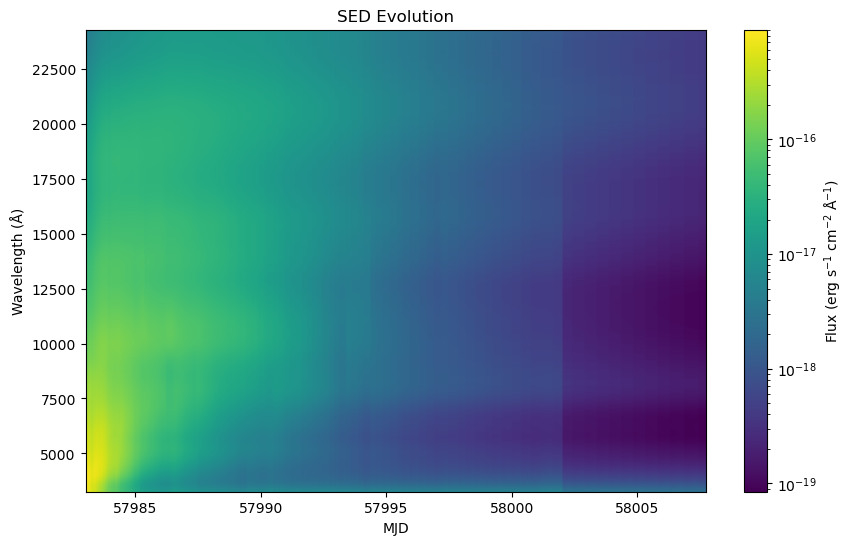

In [41]:
plot_sed_evolution(lookup_table, common_wavelengths, spec_mjds)


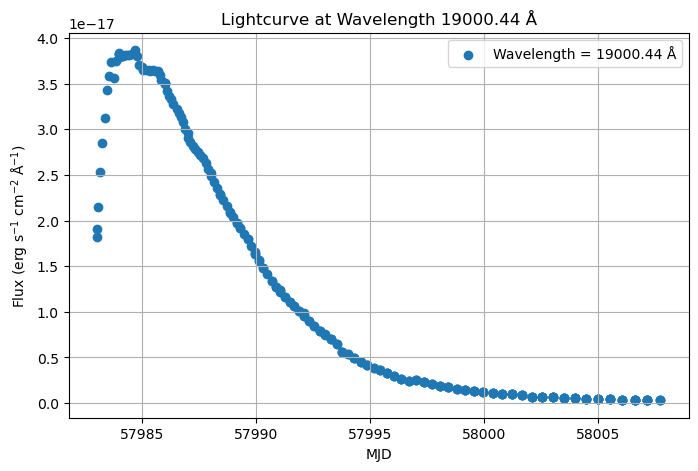

In [47]:
plot_lightcurve(19000, lookup_table)

In [ ]:
compare_lightcurves_mag(
    FILTER_PATH+"FLAMINGOS-2_Ks.dat",
    COCO_PATH+"Inputs/Photometry/1_LCs_flux_raw/AT2017gfo.dat",
    spectra_list=spectra_list,
    system="abmag",
    mjd0=57982.52851852
)

In [ ]:
compare_lightcurves_mag(
    FILTER_PATH+"DECam_i.dat",
    COCO_PATH+"Inputs/Photometry/1_LCs_flux_raw/AT2017gfo.dat",
    spectra_list=spectra_list,
    system="abmag",
    mjd0=57982.52851852
)

In [ ]:
compare_lightcurves_mag(
    FILTER_PATH+"DECam_g.dat",
    COCO_PATH+"Inputs/Photometry/1_LCs_flux_raw/AT2017gfo.dat",
    spectra_list=spectra_list,
    system="abmag",
    mjd0=57982.52851852
)

In [ ]:
compare_lightcurves_mag(
    FILTER_PATH+"Swope_g.dat",
    COCO_PATH+"Inputs/Photometry/1_LCs_flux_raw/AT2017gfo.dat",
    spectra_list=spectra_list,
    system="abmag",
    mjd0=57982.52851852
)

In [ ]:
compare_lightcurves_mag(
    FILTER_PATH+"DECam_i.dat",
    COCO_PATH+"Inputs/Photometry/1_LCs_flux_raw/AT2017gfo.dat",
    spectra_list=spectra_list,
    system="abmag",
    mjd0=57982.52851852
)

In [ ]:
explosion_mjd = 57982.52851852
data_file = COCO_PATH + "Inputs/Photometry/1_LCs_flux_raw/AT2017gfo.dat"
df = pd.read_csv(data_file)
print("photometry earliest MJD (all bands):", df["MJD"].min())
print("photometry earliest MJD (DECam_i band):", df[df["band"]=="DECam_i"]["MJD"].min())

In [ ]:
syn_times, syn_mags = synthetic_lightcurve(FILTER_PATH + "DECam_i.dat",
                                           system="abmag",
                                           spectra_list=spectra_list)
print("syn_times (MJD) first values:", syn_times[:6])


In [ ]:
syn_times_since_explosion = syn_times - explosion_mjd
print("syn_times since explosion (days) first values:", syn_times_since_explosion[:6])


In [ ]:
df = pd.read_csv(COCO_PATH+"Inputs/Photometry/1_LCs_flux_raw/AT2017gfo.dat")
obs = df[df["band"] == 'Swope_i'].copy()

In [ ]:
plt.scatter(obs['MJD'], obs['Mag'])
plt.gca().invert_yaxis()

In [ ]:
compare_sed_and_original_spectrum(
    mjd_query=57983.0,
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57982.52851852,
    list_file="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list",
    mode='smoothed',
    time_window=0.5  # will include all spectra within ±0.5 days,
    use_native_final_grid=True,
)

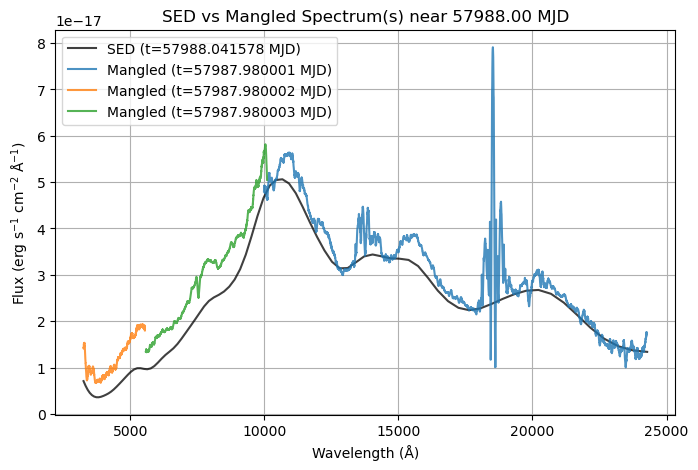

In [15]:
compare_sed_and_original_spectrum(
    mjd_query=57988,
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57982.52851852,
    #list_file="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list",
    mode='mangled',
    time_window=0.5,  # will include all spectra within ±0.5 days,
    use_native_final_grid=True,
)

In [ ]:
compare_sed_and_original_spectrum(
    mjd_query=57984.0,
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57982.52851852,
    #list_file="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list",
    mode='mangled',
    time_window=0.5,  # will include all spectra within ±0.5 days,
    use_native_final_grid=True,
)

In [ ]:
compare_sed_and_original_spectrum(
    mjd_query=57986.0,
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57982.52851852,
    #list_file="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list",
    mode='mangled',
    time_window=0.5  # will include all spectra within ±0.5 days,
    use_native_final_grid=True,
)

In [ ]:
compare_sed_and_original_spectrum(
    mjd_query=57996.0,
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57982.52851852,
    #list_file="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list",
    mode='mangled',
    time_window=0.5  # will include all spectra within ±0.5 days,
    use_native_final_grid=True,
)

In [ ]:
#THIS IS THE CORRECT TESTING CELL

compare_sed_spectrum_test(
    mjd_query=58003.0,
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57982.52851852,
    list_file=None,
    #57982.52851852
    #list_file="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list",
    mode='mangled',
    time_window=0.5  # will include all spectra within ±0.5 days
)

In [ ]:
compare_sed_and_original_spectrum(
    mjd_query=57987.0,
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57982.52851852,
    list_file="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list",
    mode='smoothed',
    time_window=0.5  # will include all spectra within ±0.5 days,
    use_native_final_grid=True,
)

In [ ]:
compare_sed_and_original_spectrum(
    mjd_query=57987.0,
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57982.52851852,
    list_file="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list",
    mode='smoothed',
    time_window=0.5  # will include all spectra within ±0.5 days,
    use_native_final_grid=True,
)

In [ ]:
compare_sed_and_original_spectrum(
    mjd_query=57988.0,
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57982.52851852,
    list_file="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list",
    mode='smoothed',
    time_window=0.5  # will include all spectra within ±0.5 days,
    use_native_final_grid=True,
)

In [ ]:
compare_sed_and_original_spectrum(
    mjd_query=57989.0,
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57983.01825,
    list_file="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list",
    mode='smoothed',
    time_window=0.5  # will include all spectra within ±0.5 days,
    use_native_final_grid=True,
)

In [ ]:
compare_sed_and_original_spectrum(
    mjd_query=57990.0,
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57983.01825,
    list_file="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list",
    mode='smoothed',
    time_window=0.5  # will include all spectra within ±0.5 days,
    use_native_final_grid=True,
)

In [ ]:
compare_sed_and_original_spectrum(
    mjd_query=57991.0,
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57983.01825,
    list_file="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list",
    mode='smoothed',
    time_window=0.5,
    use_native_final_grid=True,
) # will include all spectra within ±0.5 days

In [ ]:
compare_sed_and_original_spectrum(
    mjd_query=57992.0,
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57983.01825,
    list_file="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list",
    mode='smoothed',
    time_window=0.5,
    use_native_final_grid=True,
) # will include all spectra within ±0.5 days

In [ ]:
compare_sed_and_original_spectrum(
    mjd_query=57993.0,
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57983.01825,
    list_file="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list",
    mode='smoothed',
    time_window=0.5,
    use_native_final_grid=True,
) # will include all spectra within ±0.5 days

In [ ]:
compare_sed_and_original_spectrum(
    mjd_query=57994.0,
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57983.01825,
    list_file="/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list",
    mode='smoothed',
    time_window=0.5,
    use_native_final_grid=True,
) # will include all spectra within ±0.5 days

## testing lightcurve function that plots multiple at once

In [ ]:
def compare_lightcurves_mag(
    filter_files,
    data_file,   # a single photometry file with all filters
    lookup_table=None,
    common_wavelengths=None,
    spectra_list=None,
    system="abmag",
    mjd0=None
):
    """
    Compare synthetic lightcurves in AB mag to observed photometry, 
    for one or multiple filters.

    Parameters
    ----------
    filter_files : str or list of str
        Filter transmission curve files (e.g., ["Swope_g.dat", "FourStar_H.dat"]).
    data_file : str
        CSV with observed photometry (must contain 'MJD','Mag','Mag_err','band').
    lookup_table, common_wavelengths, spectra_list : see synthetic_lightcurve
    system : str
        Magnitude system ("abmag", "vegamag", etc.).
    mjd0 : float, optional
        Reference MJD. If None, uses the earliest observed MJD across all filters.
    """
    import matplotlib.pyplot as plt
    import numpy as np
    import pandas as pd
    import os

    # normalize input
    if isinstance(filter_files, str):
        filter_files = [filter_files]

    # load observed data
    df = pd.read_csv(data_file)

    # decide mjd0 if not provided
    if mjd0 is None:
        mjd0 = df["MJD"].min()

    fig, ax = plt.subplots(figsize=(8, 6))
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for k, filter_file in enumerate(filter_files):
        # band name inferred from filter file name
        bandname = os.path.basename(filter_file).replace(".dat", "")

        # synthetic lightcurve for this filter
        syn_times, syn_mags = synthetic_lightcurve(
            filter_file,
            system=system,
            lookup_table=lookup_table,
            common_wavelengths=common_wavelengths,
            spectra_list=spectra_list
        )
        syn_times = syn_times  # already in days-from-start

        # pick a color for this filter
        color = color_cycle[k % len(color_cycle)]

        # observed data for this filter
        obs = df[df["band"] == bandname].copy()
        if obs.empty:
            print(f"⚠️ No photometry found for band '{bandname}' in {data_file}")
            continue
        obs["time"] = obs["MJD"] - mjd0

        # plot observed
        ax.errorbar(
            obs["time"], obs["Mag"], yerr=obs["Mag_err"],
            fmt="o", label=f"Obs {bandname}",
            color=color, alpha=0.9
        )

        # plot synthetic
        ax.plot(
            syn_times, syn_mags,
            "-", label=f"SED {bandname}",
            color=color, lw=2, alpha=0.7
        )

    ax.set_xlabel(f"Time since {mjd0:.2f} MJD (days)")
    ax.set_ylabel("AB mag")
    ax.set_title("Observed vs Synthetic Lightcurves")
    ax.invert_yaxis()  # brighter = up
    ax.legend()
    fig.tight_layout()
    plt.show()

In [ ]:
compare_lightcurves_mag(
    filter_files=["Swope_i.dat", "Swope_w.dat", "FourStar_H.dat"],
    data_file="photometry.csv",
    lookup_table=lookup_table,
    common_wavelengths=common_wavelengths,
    spectra_list=spectra_list,
    system="abmag"
)

In [ ]:
import numpy as np

wavelengths = np.arange(1500, 25001, 10)  # 1500–25000 Å in steps of 100
phases = np.arange(0, 201, 1)              # 0–200 days
flat_value = 1.0

with open("prior_flat.txt", "w") as f:
    for wl in wavelengths:
        for ph in phases:
            f.write(f"{wl:.1f},{ph:.1f},{flat_value:.2f}\n")

## testing plotting mangled spectra

In [ ]:
def compare_sed_and_spectra(
    mjd_query,
    lookup_table,
    wavelengths,
    mjd0,
    list_file=None,
    original_spec_dir=None,
    ax=None,
    mode="original",
    time_window=0.,
    z=0.00984,
    use_native_final_grid=False,
    final_data_dir=None,
    sed_scale=1.0,
    snname=None,
    flux_on_disk=None,
):
    """
    Plot SED spectrum and original, smoothed, or mangled input spectrum at the closest time 
    to mjd_query. If time_window > 0, plot all spectra within ±time_window of mjd_query.

    Parameters
    ----------
    mjd_query : float
        MJD to query for the spectrum.
    lookup_table : pd.DataFrame
        SED lookup table with time as index and wavelengths as columns.
    wavelengths : np.ndarray
        Common wavelength grid.
    mjd0 : float
        Reference MJD for SED times.
    list_file : str, optional
        Path to the list file for original or smoothed spectra. Not needed for mangled.
    original_spec_dir : str, optional
        Directory containing the spectra files. Defaults based on mode.
    ax : matplotlib.axes.Axes, optional
        Axes to plot on. If None, creates a new figure.
    mode : str
        "original", "smoothed", or "mangled".
    time_window : float
        Time window in days to include multiple spectra.
    z : float
        Redshift for correction (inputs only in native path; see shared compare docstring).
    use_native_final_grid : bool
        If True, delegate to ``compare_sed_and_original_spectrum`` with native FINAL λ from disk.
    final_data_dir : str or None
        FINAL spectra directory when using native mode (else ignored for legacy path).
    sed_scale : float
        Only used when ``use_native_final_grid`` is True; multiplies the FINAL flux.
    snname : str or None
        Supernova name for native loading; defaults to global ``SNNAME`` when delegating.
    flux_on_disk : str or None
        Mangled flux interpretation when delegating; ``None`` uses ``FINAL_FLUX_ON_DISK``.
    """
    import matplotlib.pyplot as plt
    import os
    import numpy as np

    if use_native_final_grid:
        _fod = FINAL_FLUX_ON_DISK if flux_on_disk is None else flux_on_disk
        _sn = snname if snname is not None else SNNAME
        return compare_sed_and_original_spectrum(
            mjd_query,
            lookup_table,
            wavelengths,
            mjd0,
            list_file=list_file,
            original_spec_dir=original_spec_dir,
            ax=ax,
            mode=mode,
            time_window=time_window,
            z=z,
            sed_scale=sed_scale,
            snname=_sn,
            flux_on_disk=_fod,
            use_native_final_grid=True,
            final_data_dir=final_data_dir,
        )

    # --- SED spectrum ---
    sed_time = mjd_query - mjd0
    closest_sed_time = lookup_table.index[np.argmin(np.abs(lookup_table.index - sed_time))]
    sed_flux = lookup_table.loc[closest_sed_time].values

    # --- Choose list and directory based on mode ---
    if mode == "smoothed":
        if list_file is None:
            list_file = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/2_spec_lists_smoothed/AT2017gfo.list"
        list_file = list_file.replace("1_spec_lists_original", "2_spec_lists_smoothed")
        if original_spec_dir is None:
            original_spec_dir = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/2_spec_smoothed"
    elif mode == "mangled":
        # Default mangled directory
        if original_spec_dir is None:
            original_spec_dir = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Outputs/AT2017gfo/mangled_spectra"
        # For mangled, scan directory for .txt files
        orig_paths = sorted([f for f in os.listdir(original_spec_dir) if f.endswith(".txt")])
        orig_mjds = []
        for fname in orig_paths:
            try:
                orig_mjds.append(float(fname.split("_")[0]))
            except Exception:
                orig_mjds.append(np.nan)
    else:
        # original mode (default)
        if original_spec_dir is None:
            original_spec_dir = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_original"
        if list_file is None:
            list_file = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list"

    # Load from list_file if not mangled
    if mode != "mangled":
        orig_paths, orig_mjds = [], []
        with open(list_file) as f:
            for line in f:
                if line.strip() == "" or line.startswith("#"):
                    continue
                parts = line.split()
                if mode == "smoothed":
                    if len(parts) < 3:
                        continue
                    try:
                        orig_mjds.append(float(parts[0]))
                        orig_paths.append(parts[2])
                    except Exception:
                        continue
                else:
                    if len(parts) < 3:
                        continue
                    try:
                        orig_paths.append(parts[0])
                        orig_mjds.append(float(parts[-1]))
                    except Exception:
                        continue

    # Ensure we have lists
    try:
        orig_mjds = np.array(orig_mjds)
    except Exception:
        orig_mjds = np.array([])

    if not orig_paths or orig_mjds.size == 0:
        print(f"No valid spectra found for mode '{mode}' in {list_file or original_spec_dir}")
        return

    # --- Select spectra ---
    if time_window > 0:
        idxs = np.where(np.abs(orig_mjds - mjd_query) <= time_window)[0]
        if len(idxs) == 0:
            idxs = [np.argmin(np.abs(orig_mjds - mjd_query))]
    else:
        idxs = [np.argmin(np.abs(orig_mjds - mjd_query))]

    # --- Plot ---
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 5))

    # Plot SED first
    ax.plot(
        wavelengths, sed_flux,
        label=f"SED (t={closest_sed_time + mjd0:.6f} MJD)",
        color="black",
        alpha=0.75
    )

    label = "Smoothed" if mode == "smoothed" else ("Mangled" if mode == "mangled" else "Original")

    # Color cycle for multiple spectra
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

    for j, idx in enumerate(idxs):
        orig_path = orig_paths[idx]
        orig_mjd = orig_mjds[idx]

        # --- Fix local path if needed ---
        if orig_path.startswith("/data/1_spec_original/") or orig_path.startswith("/data/2_spec_smoothed/"):
            if mode == "smoothed":
                local_base = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/2_spec_smoothed"
                orig_path = os.path.join(local_base, orig_path.replace("/data/2_spec_smoothed/", ""))
            else:
                local_base = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_original"
                orig_path = os.path.join(local_base, orig_path.replace("/data/1_spec_original/", ""))
        elif not orig_path.startswith("/"):
            orig_path = os.path.join(original_spec_dir, orig_path)
        orig_path = os.path.expanduser(orig_path)

        # --- Load spectrum ---
        try:
            orig_data = np.loadtxt(orig_path)
            orig_wl = orig_data[:, 0]
            orig_flux = orig_data[:, 1]
        except Exception as e:
            print(f"Could not load spectrum: {orig_path}\n{e}")
            continue
        
        if z > 0.0:
            orig_wl = orig_wl / (1 + z)
            orig_flux = orig_flux * (1 + z)
        
        # --- Plot spectrum ---
        ax.plot(
            orig_wl, orig_flux,
            label=f"{label} (t={orig_mjd:.6f} MJD)",
            color=color_cycle[j % len(color_cycle)],
            alpha=0.8
        )

    ax.set_xlabel("Wavelength (Å)")
    ax.set_ylabel(r"Flux (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)")
    ax.set_title(f"SED vs {label} Spectrum(s) near {mjd_query:.2f} MJD")
    ax.legend()
    ax.grid()
    plt.show()

In [ ]:
compare_sed_and_spectra(
    mjd_query=57987.0,
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57982.52851852,
    list_file=None,
    original_spec_dir=None,
    ax=None,
    mode="mangled",
    time_window=0.5,
    z=0.00984
)

In [ ]:
def plot_spectral_series(
    lookup_table,
    wavelengths,
    mjd0,
    time_interval=1.0,
    offset=True,
    overplot_mode="none",
    list_file=None,
    original_spec_dir=None,
    colors=None,
    z=0.00984,
    time_window=0.5,
    spec_dir=None,
    first_spec_mjd=None,
    max_plots=None,
    min_sep=0.05,
    use_native_final_grid=False,
    final_data_dir=None,
    snname=None,
):
    """
    Plot a spectral series from SED output spectra at specified time intervals.

    Behavior:
    - Build a regular desired-MJD grid starting at `mjd0` with spacing `time_interval`.
    - For each desired MJD, select the nearest SED output spectrum (lookup_table rows
      are days-from-first-spectrum) if that spectrum is within `time_window` days.
    - Plot modes:
        * offset=True  : vertical stacking (no numeric y-ticks), each spectrum colored
                         and labeled at the right end with its actual MJD.
        * offset=False : real flux values, colored, labeled similarly.
    - Optionally overplot input spectra ("original","smoothed","mangled") matched to
      each plotted SED spectrum (using the same time_window tolerance).
    - Colors: use provided list or matplotlib default cycle.
    - You can provide `first_spec_mjd` (absolute MJD of lookup_table index==0),
      or `spec_dir` (directory with SED files named like "57983.991400_...") to infer it.
    - min_sep : minimum vertical separation between adjacent stacked spectra (in normalized units).
    - use_native_final_grid : if True, each SED trace is the nearest FINAL spectrum on disk (native λ);
      requires ``data_dir``/``spec_dir``/``final_data_dir`` and ``SNNAME`` (or pass ``snname``).
    """
    import numpy as np
    import matplotlib.pyplot as plt
    import os
    import glob

    # --- determine mjd_ref (absolute MJD that corresponds to lookup_table.index == 0) ---
    if first_spec_mjd is not None:
        mjd_ref = float(first_spec_mjd)
    else:
        # prefer explicit spec_dir, else try global data_dir if available, else try common default
        spec_dir = spec_dir or globals().get("data_dir") or \
                   "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Outputs/AT2017gfo/FINAL_spectra_2dim/as_observed"
        if os.path.isdir(spec_dir):
            files = sorted([os.path.basename(f) for f in os.listdir(spec_dir) if "_" in f])
            mjds = []
            for fn in files:
                try:
                    mjds.append(float(fn.split("_")[0]))
                except Exception:
                    continue
            if len(mjds) > 0:
                mjd_ref = float(min(mjds))
            else:
                print("⚠️ Couldn't infer first-spec MJD from spec_dir; using mjd0 as fallback (labels may be off).")
                mjd_ref = float(mjd0)
        else:
            print("⚠️ spec_dir not found and first_spec_mjd not provided; using mjd0 as fallback (labels may be off).")
            mjd_ref = float(mjd0)

    # absolute MJDs of SED spectra
    if hasattr(lookup_table, "attrs") and "spec_mjd" in lookup_table.attrs:
        sed_abs_mjds = np.asarray(lookup_table.attrs["spec_mjd"], dtype=float)
    else:
        sed_abs_mjds = lookup_table.index.to_numpy(dtype=float) + mjd_ref

    # build desired MJD grid starting at mjd0
    last_mjd = np.nanmax(sed_abs_mjds)
    desired_mjds = np.arange(mjd0, last_mjd + 0.5 * time_interval, time_interval)

    # pick nearest available SED spectrum for each desired MJD within time_window
    chosen_idxs = []
    for dm in desired_mjds:
        diffs = np.abs(sed_abs_mjds - dm)
        idx = int(np.argmin(diffs))
        if diffs[idx] <= time_window:
            chosen_idxs.append(idx)
    # keep order and make unique
    chosen_idxs = list(dict.fromkeys(chosen_idxs))

    if len(chosen_idxs) == 0:
        print("No SED spectra found within the requested time window. Increase time_window or check mjd0/spec_dir.")
        return None

    # prepare colors
    if colors is None:
        color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    else:
        color_cycle = list(colors)

    # compute per-spectrum offsets if requested
    raw_wl_list = None
    raw_fl_list = None
    if use_native_final_grid:
        fdir = final_data_dir or spec_dir or globals().get("data_dir")
        _sn = snname if snname is not None else globals().get("SNNAME", None)
        if not fdir or _sn is None:
            raise ValueError(
                "use_native_final_grid=True needs final_data_dir/spec_dir/data_dir and SNNAME in globals or snname="
            )
        raw_wl_list, raw_fl_list = [], []
        for ii in chosen_idxs:
            sm = float(sed_abs_mjds[ii])
            _, wl_n, fl_n, _ = nearest_final_spectrum_native(
                fdir,
                sm,
                globals()["COCO_PATH"],
                _sn,
                flux_on_disk=globals().get("FINAL_FLUX_ON_DISK", "auto"),
                datalc_path=globals().get("DATALC_PATH"),
                final_suffixes=globals().get("FINAL_SUFFIXES_TO_LOAD"),
            )
            raw_wl_list.append(wl_n)
            raw_fl_list.append(fl_n.astype(float))

    if offset:
        norm_spectra = []
        if use_native_final_grid:
            for fl in raw_fl_list:
                mx = np.nanmax(fl)
                if not np.isfinite(mx) or mx == 0:
                    norm_spectra.append(np.zeros_like(fl))
                else:
                    norm_spectra.append(fl / mx)
            offsets = np.arange(len(norm_spectra), dtype=float) * (1.0 + min_sep)
        else:
            # build normalized spectra (safe against zeros/NaNs)
            for i in chosen_idxs:
                f = lookup_table.iloc[i].values.astype(float)
                mx = np.nanmax(f)
                if not np.isfinite(mx) or mx == 0:
                    norm_spectra.append(np.zeros_like(f))
                else:
                    norm_spectra.append(f / mx)

            # iterative offsets: bottom spectrum = 0; each next one is moved up so that
            # min( (cur + off_cur) - (prev + off_prev) ) >= min_sep
            offsets = np.zeros(len(norm_spectra), dtype=float)
            for k in range(1, len(norm_spectra)):
                prev = norm_spectra[k - 1]
                cur = norm_spectra[k]
                diff = cur - prev
                min_diff = np.nanmin(diff)
                inc = max(min_sep - min_diff, 0.0)
                offsets[k] = offsets[k - 1] + inc
    else:
        offsets = None
        norm_spectra = None

    # prepare input spectra if overplotting requested
    input_paths = []
    input_mjds = []
    if overplot_mode != "none":
        if overplot_mode == "smoothed":
            if list_file is None:
                list_file = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/2_spec_lists_smoothed/AT2017gfo.list"
            list_file = list_file.replace("1_spec_lists_original", "2_spec_lists_smoothed")
            if original_spec_dir is None:
                original_spec_dir = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/2_spec_smoothed"
        elif overplot_mode == "mangled":
            if original_spec_dir is None:
                original_spec_dir = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Outputs/AT2017gfo/mangled_spectra"
            exts = ("*.txt", "*.dat", "*.asc", "*.spec", "*.ascii", "*.pdf")
            files = []
            for e in exts:
                files.extend(sorted(glob.glob(os.path.join(original_spec_dir, e))))
            for p in files:
                bn = os.path.basename(p)
                try:
                    m = float(bn.split("_")[0])
                    input_paths.append(p)
                    input_mjds.append(m)
                except Exception:
                    continue
        else:  # original
            if original_spec_dir is None:
                original_spec_dir = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_original"
            if list_file is None:
                list_file = "/Users/ravkaur/Desktop/research/kilonova-SED/PyCoCo_templates/Inputs/Spectroscopy/1_spec_lists_original/AT2017gfo.list"
        if overplot_mode in ("original", "smoothed"):
            input_paths = []
            input_mjds = []
            with open(list_file) as f:
                for line in f:
                    if line.strip() == "" or line.startswith("#"):
                        continue
                    parts = line.split()
                    if overplot_mode == "smoothed":
                        if len(parts) >= 3:
                            try:
                                input_mjds.append(float(parts[0]))
                                p = parts[2]
                                p = p if p.startswith("/") else os.path.join(original_spec_dir, p)
                                input_paths.append(p)
                            except Exception:
                                continue
                    else:
                        if len(parts) >= 1:
                            try:
                                p = parts[0]
                                p = p if p.startswith("/") else os.path.join(original_spec_dir, p)
                                input_paths.append(p)
                                input_mjds.append(float(parts[-1]))
                            except Exception:
                                continue
            input_mjds = np.array(input_mjds) if input_mjds else np.array([])

    # plotting
    fig, ax = plt.subplots(figsize=(16,24))
    ax.set_xlabel("Wavelength (Å)")
    if offset:
        ax.set_ylabel("Flux (offset)")
        ax.set_yticks([])
    else:
        ax.set_ylabel(r"Flux (erg s$^{-1}$ cm$^{-2}$ Å$^{-1}$)")

    for j, idx in enumerate(chosen_idxs):
        sed_mjd = float(sed_abs_mjds[idx])
        phase_days = sed_mjd - mjd0
        color = color_cycle[j % len(color_cycle)]
        if use_native_final_grid:
            wl_n = raw_wl_list[j]
            fl_n = raw_fl_list[j]
            if offset:
                y_offset = offsets[j]
                plot_flux = norm_spectra[j] + y_offset
            else:
                y_offset = 0.0
                plot_flux = fl_n
            ax.plot(wl_n, plot_flux, color=color, linewidth=1.5)
            ax.text(
                wl_n[-1] + max((wl_n[-1] - wl_n[0]) * 0.005, 1.0),
                plot_flux[-1],
                f"{sed_mjd:.6f}",
                color=color,
                fontsize=9,
                verticalalignment="center"
            )
        else:
            sed_flux = lookup_table.iloc[idx].values
            if offset:
                y_offset = offsets[j]
                plot_flux = norm_spectra[j] + y_offset
            else:
                y_offset = 0.0
                plot_flux = sed_flux

            # plot SED spectrum (no legend entry)
            ax.plot(wavelengths, plot_flux, color=color, linewidth=1.5)

            ax.text(
                wavelengths[-1] + (wavelengths[-1] - wavelengths[0]) * 0.005,
                plot_flux[-1],
                f"{sed_mjd:.6f}",
                color=color,
                fontsize=9,
                verticalalignment="center"
            )

        # optionally overplot input spectrum matched by MJD
        if overplot_mode != "none" and len(input_mjds) > 0:
            diffs = np.abs(np.array(input_mjds) - sed_mjd)
            closest = int(np.argmin(diffs))
            if diffs[closest] <= time_window:
                input_path = input_paths[closest]
                try:
                    data = np.loadtxt(input_path)
                    wl = data[:, 0]
                    fl = data[:, 1]
                    if z > 0.0:
                        wl = wl / (1 + z)
                        fl = fl * (1 + z)
                    # shift overlay by same y_offset (if offsetting, overlay will likely need scaling to match)
                    ax.plot(wl, fl + y_offset, color=color, linestyle="--", alpha=0.8)
                except Exception as e:
                    print(f"Could not load/plot input spectrum: {input_path} — {e}")

        # limit number plotted if requested
        if (max_plots is not None) and (j + 1 >= max_plots):
            break

    ax.set_title(f"Spectral Series every {time_interval} d (start {mjd0:.2f} MJD)")
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    plt.show()

    return ax
# ...existing code...

In [ ]:
plot_spectral_series(
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57982.52851852,
    time_interval=1.0,
    offset=False,
    overplot_mode="none",
    list_file=None,
    original_spec_dir=None,
    colors=None,
    z=0.00984,
    time_window=0.5,
    spec_dir=None,
    first_spec_mjd=None,
    max_plots=None
)

In [ ]:
plot_spectral_series(
    lookup_table=lookup_table,
    wavelengths=common_wavelengths,
    mjd0=57982.52851852,
    time_interval=1.0,
    offset=True,
    overplot_mode="none",
    list_file=None,
    original_spec_dir=None,
    colors=None,
    z=0.00984,
    time_window=0.5,
    spec_dir=None,
    first_spec_mjd=None,
    max_plots=None,
    min_sep=0.05
)

In [ ]:
def plot_synthetic_lightcurves(
    filters,
    lookup_table=None,
    common_wavelengths=None,
    spectra_list=None,
    system="abmag",
    filter_dir=None,
    colors=None,
    labels=None,
    mjd0=None,
    ax=None,
    marker=None,
    linewidth=2.0,
    alpha=0.9,
    ext=".dat"
):
    """
    Plot synthetic lightcurves for a list of filters (by name or full path).

    - filters : str or list[str]
        Filter basenames (e.g. "Swope_i" or "Swope_i.dat") or full paths.
        If basename is provided, the function will look for the file in
        `filter_dir` (defaults to FILTER_PATH if available, else a sensible default).
    - lookup_table/common_wavelengths OR spectra_list : as for synthetic_lightcurve
    - system : photometric system to pass to synthetic_lightcurve ("abmag" default)
    - filter_dir : directory to search for filter files (defaults to FILTER_PATH)
    - colors : list[str], optional color list; will cycle if shorter than filters
    - labels : list[str] optional labels for inline text; defaults to filter basenames
    - mjd0 : float, optional; if provided, syn_times will be plotted as (syn_times - mjd0)
    - ax : matplotlib axis to draw on (created if None)
    - marker, linewidth, alpha : plot styling
    - ext : default extension to append to basenames if missing (".dat")
    """
    import os
    import numpy as np
    import matplotlib.pyplot as plt

    # allow a single string
    if isinstance(filters, str):
        filters = [filters]

    # determine search directory for filters
    if filter_dir is None:
        filter_dir = globals().get("FILTER_PATH") or (globals().get("COCO_PATH") + "Inputs/Filters/GeneralFilters/")

    # build full paths for filter files
    filter_paths = []
    filter_basenames = []
    for f in filters:
        if os.path.isabs(f) or ("/" in f):
            # given a path-like string; append extension if missing and file not found
            fp = f if f.endswith(ext) else f + ext
            if not os.path.exists(fp):
                fp = f  # keep original and let errors surface later
        else:
            # treat as basename; try with/without extension in filter_dir
            base = f if f.endswith(ext) else f + ext
            fp = os.path.join(filter_dir, base)
            if not os.path.exists(fp):
                # try without appended ext (in case user provided it already)
                alt = os.path.join(filter_dir, f)
                fp = alt if os.path.exists(alt) else os.path.join(filter_dir, base)
        filter_paths.append(fp)
        filter_basenames.append(os.path.basename(f).replace(ext, ""))

    # labels default
    if labels is None:
        labels = filter_basenames
    if colors is None:
        color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
    else:
        color_cycle = list(colors)

    if ax is None:
        fig, ax = plt.subplots(figsize=(16, 8))

    for i, fp in enumerate(filter_paths):
        if not os.path.exists(fp):
            print(f"⚠️ filter file not found: {fp} — skipping")
            continue

        try:
            syn_times, syn_vals = synthetic_lightcurve(
                fp, system=system,
                lookup_table=lookup_table,
                common_wavelengths=common_wavelengths,
                spectra_list=spectra_list
            )
        except Exception as e:
            print(f"Could not compute synthetic LC for {fp}: {e}")
            continue

        # shift times if requested (e.g., syn_times are MJD and you want days since mjd0)
        if mjd0 is not None:
            syn_times_plot = syn_times - float(mjd0)
        else:
            syn_times_plot = syn_times

        mask = np.isfinite(syn_vals)
        if mask.sum() == 0:
            print(f"⚠️ No valid synthetic points for {fp}; skipping")
            continue

        color = color_cycle[i % len(color_cycle)]
        ax.plot(syn_times_plot[mask], syn_vals[mask],
                color=color, linewidth=linewidth, alpha=alpha, marker=marker)

        # place inline label at last valid point
        x_last = syn_times_plot[mask][-1]
        y_last = syn_vals[mask][-1]
        span = (np.nanmax(syn_times_plot[mask]) - np.nanmin(syn_times_plot[mask]))
        x_off = 0.02 * span if span > 0 else 0.1
        ax.text(x_last + x_off, y_last, labels[i], color=color, fontsize=9,
                verticalalignment="center")

    ax.set_xlabel("Time (days)" if mjd0 is not None else "Time (days from first spectrum)")
    ax.set_ylabel("Mag" if "mag" in system else "Flux / countrate")
    if "mag" in system:
        ax.invert_yaxis()
    ax.grid(True, alpha=0.25)
    plt.tight_layout()
    return ax

In [ ]:
filter_names = [
    'Swope_i',
    'FourStar_H',
    'FourStar_J',
    'DECam_i',
    'DECam_z',
    'DECam_Y',
    'FourStar_Ks',
    'UVOT_U',
    'Skymapper_i',
    'Sinistro_g',
    'Sinistro_r',
    'Skymapper_r',
    'Skymapper_g',
    'EFOSC2_V',
    'Sinistro_i',
    'DECam_r',
    'DECam_g',
    'DECam_u',
    'Swope_V',
    'FourStar_J1',
    'Swope_B',
    'Swope_r',
    'Swope_g',
    'EFOSC2_U',
    'Sinistro_V',
    'Sinistro_z',
    'IMACS_r',
    'LRIS_I',
    'SOFI_H',
    'SOFI_Ks',
    'VISTA_Ks',
    'VISTA_J',
    'VISTA_Y',
    'FLAMINGOS-2_Ks',
    'UVOT_M2',
    'UVOT_W1',
    'UVOT_W2',
    'HSC_z',
    'GFC_i',
    'GFC_y',
    'GFC_z',
    'GFC_r',
    'SIRIUS_H',
    'SIRIUS_J',
    'SIRIUS_Ks',
    'T80Cam_g',
    'GROND_H',
    'GROND_J',
    'GROND_K',
    'GROND_g',
    'GROND_i',
    'GROND_r',
    'GROND_z',
    'FLAMINGOS-2_H',
    'IMACS_i',
    'FLAMINGOS-2_J',
    'UVOT_B',
    'GMOS_g',
    'GMOS_i',
    'GMOS_r',
    'GMOS_z',
    'FORS2_R',
    'VIMOS_z',
    'FORS2_I',
    'FORS2_B',
    'FORS2_V',
    'ANDICAM_K',
    'MOIRCS_Ks',
    'HAWKI_Ks'
]

In [ ]:
plot_synthetic_lightcurves(
    filters=filter_names,
    lookup_table=lookup_table,
    common_wavelengths=common_wavelengths,
    spectra_list=None,
    system="abmag",
    filter_dir=None,
    colors=None,
    labels=None,
    mjd0=57983.01825,
    ax=None,
    marker=None,
    linewidth=2.0,
    alpha=0.9,
    ext=".dat")

In [ ]:
plot_synthetic_lightcurves(
    filters=filter_names,
    lookup_table=lookup_table,
    common_wavelengths=common_wavelengths,
    spectra_list=None,
    system="abmag",
    filter_dir=None,
    colors=None,
    labels=None,
    mjd0=None,
    ax=None,
    marker=None,
    linewidth=1.0,
    alpha=0.8,
    ext=".dat")

In [ ]:
swope = [
    'Swope_i',
    'Swope_V',
    'Swope_B',
    'Swope_r',
    'Swope_g'
]

fourstar = [
    'FourStar_H',
    'FourStar_J',
    'FourStar_Ks',
    'FourStar_J1'
]

decam = [
    'DECam_i',
    'DECam_z',
    'DECam_Y',
    'DECam_r',
    'DECam_g',
    'DECam_u'
]

uvot = [
    'UVOT_U',
    'UVOT_M2',
    'UVOT_W1',
    'UVOT_W2',
    'UVOT_B'
]

skymapper = [
    'Skymapper_i',
    'Skymapper_r',
    'Skymapper_g'
]

sinistro = [
    'Sinistro_i',
    'Sinistro_V',
    'Sinistro_z'
]

efosc2 = [
    'EFOSC2_V',
    'EFOSC2_U'
]

imacs = [
    'IMACS_r',
    'IMACS_i'
]

lris = [
    'LRIS_I'
]

sofi = [
    'SOFI_H',
    'SOFI_Ks'
]

vista = [
    'VISTA_Ks',
    'VISTA_J',
    'VISTA_Y'
]

flamingos = [
    'FLAMINGOS-2_Ks',
    'FLAMINGOS-2_H',
    'FLAMINGOS-2_J'
]

hsc = [
    'HSC_z'
]

gfc = [
    'GFC_i',
    'GFC_y',
    'GFC_z',
    'GFC_r'
]

sirius = [
    'SIRIUS_H',
    'SIRIUS_J',
    'SIRIUS_Ks'
]

t80cam = [
    'T80Cam_g'
]

grond = [
    'GROND_H',
    'GROND_J',
    'GROND_K',
    'GROND_g',
    'GROND_i',
    'GROND_r',
    'GROND_z'
]

gmos = [
    'GMOS_g',
    'GMOS_i',
    'GMOS_r',
    'GMOS_z'
]

fors2 = [
    'FORS2_R',
    'FORS2_I',
    'FORS2_B',
    'FORS2_V'
]

vimos = [
    'VIMOS_z'
]

other_kband = [
    'ANDICAM_K',
    'MOIRCS_Ks',
    'HAWKI_Ks'
]

In [ ]:
plot_synthetic_lightcurves(
    filters=grond,
    lookup_table=lookup_table,
    common_wavelengths=common_wavelengths,
    spectra_list=None,
    system="abmag",
    filter_dir=None,
    colors=None,
    labels=None,
    #mjd0=57982.52851852,
    ax=None,
    marker=None,
    linewidth=1.0,
    alpha=0.8,
    ext=".dat")